# Performance on real microscopic data

Here, we're using the model with labeled images of E.coli, kindly provided by Yundon


In [1]:
import os
from scipy.io import loadmat
import numpy as np
import PIL.Image
from tqdm import tqdm
import matplotlib.pyplot as plt

First, we need to convert the data into the YOLO dataset format. We cut the original $1280\times1080\,\text{px}$ image into four equal quadrants and save the corresponding txt file.
The last image set is not used for training, it will be used only for testing and evaluating the model performance.

In [ ]:
image_set_path = "../datasets/Zstack_DownSampled_BGCorrected_TrackingData"
image_sets = [image_set_path+"/"+entry for entry in os.listdir(image_set_path) if entry.startswith("Image Set")]
image_sets.sort()
image_sets.pop() #remove last image set from list, it will be used for testing!

print("available img sets:", image_sets)

dataset_path = "../datasets/Dataset_yundon"
os.makedirs(dataset_path+"/images/train", exist_ok=True)
os.makedirs(dataset_path+"/images/val", exist_ok=True)
os.makedirs(dataset_path+"/labels/train", exist_ok=True)
os.makedirs(dataset_path+"/labels/val", exist_ok=True)

train_val_split = 0.95 # 5% of the image will land in the val folder

for set_number, image_set in enumerate(image_sets, start=1):
    files_in_img_set_folder = [entry for entry in os.listdir(image_set) if not entry.startswith(".")]
    tifs = [image_set+"/"+entry for entry in files_in_img_set_folder if entry.endswith(".tif")]
    tifs.sort()
    print(tifs)
    image_objects = [PIL.Image.open(tif) for tif in tifs]

    matfile = [image_set+"/"+entry for entry in files_in_img_set_folder if entry.endswith(".mat")][0]
    x,y,z0 = [v.astype(np.float32) for v in loadmat(matfile)['BugXYZPositionAmpFinal'].T[:3]]

    x /= 0.325*640 #normalize x and y to [0,2]
    y /= 0.325*540

    # with this mask, we later filter out the visible particles in each quadrant
    quadrants_masks = [((y <  1) & (x <  1)), #top left ...
                      ((y <  1) & (x >= 1)),
                      ((y >= 1) & (x <  1)),
                      ((y >= 1) & (x >= 1))] # bottom right
    
    # with these slices, we cut the image array into quadrants
    quadrant_slices = [np.s_[:540,:640], #top left...
                       np.s_[:540,640:],
                       np.s_[540:,:640],
                       np.s_[540:,640:]] #bottom right
    
    # make x,y relative to quadrant and [0,1]
    x = x%1
    y = y%1

    class_id = np.zeros_like(x) #make dummy class id (always 0)

    
    progress_bar = tqdm(range(1501), desc=image_set)
    for z_level in progress_bar: # there are 1501 total z levels in each stack
        image_obj = image_objects[z_level//387]
        #set z and bounding box sizes for current z_level
        z = 0.2676 * z_level - z0
        bw = (np.abs(z)/0.161*0.21+55)
        bh = bw.copy()
        bw/=640
        bh/=540

        z_mask = (z > -102) & (z < 108)

        image_obj.seek(z_level % 387) #each image file has 387 frames
        image_array = np.array(image_obj).astype(np.uint16) #cast image to 16 bit int numpy array

        for quadrant_number, (quadrant_mask, quadrant_slice) in enumerate(zip(quadrants_masks, quadrant_slices)): #go through the 4 quadrants
            id = f"set{set_number}_z{z_level}_q{quadrant_number}" #ID used in filenames

            mode = "val" if np.random.random()>train_val_split else "train"
            image_fname = dataset_path+f"/images/{mode}/"+id+".tif"
            label_fname = dataset_path+f"/labels/{mode}/"+id+".txt"

            sliced_array = image_array[quadrant_slice] #get current slice from image array

            with PIL.Image.fromarray(sliced_array) as sliced_img:
                sliced_img.save(image_fname, quality=100) #save current slice

            
            data = np.column_stack([class_id,x.clip(0,1),y.clip(0,1),bw.clip(0,1),bh.clip(0,1),z, x.clip(0,1), y.clip(0,1)])[quadrant_mask & z_mask]

            np.savetxt(label_fname, data, fmt='%g')

    [img.close() for img in image_objects] #close images





/tmp/ipykernel_788256/1117354441.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x,y,z0 = [v.astype(np.float32) for v in loadmat(matfile)['BugXYZPositionAmpFinal'].T[:3]]


available img sets: ['../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 1 - 250319', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 2 - 250616', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 3 - 250616', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 4 - 250616', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 5 - 250616', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 6 - 250616', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 7 - 250616']
['../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 1 - 250319/BGC101_H2V2Z1_Ch1_zstack_1_MMStack_Pos0.ome.tif', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 1 - 250319/BGC101_H2V2Z1_Ch1_zstack_1_MMStack_Pos0_1.ome.tif', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 1 - 250319/BGC101_H2V2Z1_Ch1_zstack_1_MMStack_Pos0_2.ome.tif', '../datasets/Zstack_DownSample

../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 1 - 250319: 100%|██████████| 1501/1501 [00:09<00:00, 163.16it/s]


['../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 2 - 250616/BGC101_H2V2Z1_Ch1_zstack_2_MMStack_Pos0.tif', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 2 - 250616/BGC101_H2V2Z1_Ch1_zstack_2_MMStack_Pos0_1.tif', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 2 - 250616/BGC101_H2V2Z1_Ch1_zstack_2_MMStack_Pos0_2.tif', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 2 - 250616/BGC101_H2V2Z1_Ch1_zstack_2_MMStack_Pos0_3.tif']


../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 2 - 250616: 100%|██████████| 1501/1501 [00:09<00:00, 152.70it/s]


...

../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 5 - 250616: 100%|██████████| 1501/1501 [00:09<00:00, 151.88it/s]


['../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 6 - 250616/BGC101_H2V2Z1_Ch3_zstack_2_MMStack_Pos0.ome.tif', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 6 - 250616/BGC101_H2V2Z1_Ch3_zstack_2_MMStack_Pos0_1.ome.tif', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 6 - 250616/BGC101_H2V2Z1_Ch3_zstack_2_MMStack_Pos0_2.ome.tif', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 6 - 250616/BGC101_H2V2Z1_Ch3_zstack_2_MMStack_Pos0_3.ome.tif']


../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 6 - 250616: 100%|██████████| 1501/1501 [00:10<00:00, 150.05it/s]


['../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 7 - 250616/BGC101_H2V2Z1_Ch3_zstack_3_MMStack_Pos0.ome.tif', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 7 - 250616/BGC101_H2V2Z1_Ch3_zstack_3_MMStack_Pos0_1.ome.tif', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 7 - 250616/BGC101_H2V2Z1_Ch3_zstack_3_MMStack_Pos0_2.ome.tif', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 7 - 250616/BGC101_H2V2Z1_Ch3_zstack_3_MMStack_Pos0_3.ome.tif']


../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 7 - 250616: 100%|██████████| 1501/1501 [00:09<00:00, 150.39it/s]


Next, we take the remaining Image set and save the labels as well. The images of this set will not be cut into fourths.

In [ ]:
image_set_path = "../datasets/Zstack_DownSampled_BGCorrected_TrackingData"
image_sets = [image_set_path+"/"+entry for entry in os.listdir(image_set_path) if entry.startswith("Image Set")]
image_sets.sort()
image_sets = image_sets[-1:]

print("available img sets:", image_sets)

dataset_path = "../datasets/Dataset_yundon"
os.makedirs(dataset_path+"/images/test", exist_ok=True)
os.makedirs(dataset_path+"/labels/test", exist_ok=True)

for set_number, image_set in enumerate(image_sets, start=8):
    files_in_img_set_folder = [entry for entry in os.listdir(image_set) if not entry.startswith(".")]
    tifs = [image_set+"/"+entry for entry in files_in_img_set_folder if entry.endswith(".tif")]
    tifs.sort()
    print(tifs)
    image_objects = [PIL.Image.open(tif) for tif in tifs]

    matfile = [image_set+"/"+entry for entry in files_in_img_set_folder if entry.endswith(".mat")][0]
    x,y,z0 = [v.astype(np.float32) for v in loadmat(matfile)['BugXYZPositionAmpFinal'].T[:3]]

    x /= 0.325*1280 #normalize x and y to [0,1]
    y /= 0.325*1080


    class_id = np.zeros_like(x) #make dummy class id (always 0)

    
    progress_bar = tqdm(range(1501), desc=image_set)
    for z_level in progress_bar: # there are 1501 total z levels in each stack
        image_obj = image_objects[z_level//387]
        #set z and bounding box sizes for current z_level
        z = 0.2676 * z_level - z0
        bw = np.abs(z)/0.161*0.21+55
        bh = bw.copy()

        bw /= 1280 
        bh /= 1080

        z_mask = (z > -102) & (z < 108)

        image_obj.seek(z_level % 387) #each image file has 387 frames
        image_array = np.array(image_obj).astype(np.uint16) #cast image to 16 bit int numpy array

        # for quadrant_number, (quadrant_mask, quadrant_slice) in enumerate(zip(quadrants_masks, quadrant_slices)): #go through the 4 quadrants
        id = f"set{set_number}_z{z_level}" #ID used in filenames
        image_fname = dataset_path+"/images/test/"+id+".tif"
        label_fname = dataset_path+"/labels/test/"+id+".txt"

        # sliced_array = image_array[quadrant_slice] #get current slice from image array

        with PIL.Image.fromarray(image_array) as img:
            img.save(image_fname, quality=100) #save current slice

        
        data = np.column_stack([class_id,x.clip(0,1),y.clip(0,1),bw.clip(0,1),bh.clip(0,1),z, x.clip(0,1), y.clip(0,1)])[z_mask]

        np.savetxt(label_fname, data, fmt='%g')

    [img.close() for img in image_objects] #close images





/tmp/ipykernel_788256/2264668856.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x,y,z0 = [v.astype(np.float32) for v in loadmat(matfile)['BugXYZPositionAmpFinal'].T[:3]]


available img sets: ['../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 8 - 250616']
['../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 8 - 250616/BGC101_H2V2Z1_Ch3_zstack_4_MMStack_Pos0.ome.tif', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 8 - 250616/BGC101_H2V2Z1_Ch3_zstack_4_MMStack_Pos0_1.ome.tif', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 8 - 250616/BGC101_H2V2Z1_Ch3_zstack_4_MMStack_Pos0_2.ome.tif', '../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 8 - 250616/BGC101_H2V2Z1_Ch3_zstack_4_MMStack_Pos0_3.ome.tif']


../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 8 - 250616:   0%|          | 0/1501 [00:00<?, ?it/s]

../datasets/Zstack_DownSampled_BGCorrected_TrackingData/Image Set 8 - 250616: 100%|██████████| 1501/1501 [00:04<00:00, 328.63it/s]


Next, we need a .yaml file for training

In [ ]:
import yaml
subdir = '../datasets/Dataset_yundon/'

file_path = '../datasets/yundon_test.yaml'

dict = {}

dict["train"]=os.getcwd() + '/' + subdir + "images/" + "train"
dict["val"]=os.getcwd() + '/' + subdir + "images/" + "val"
# dict["test"]=os.getcwd() + '/' + subdir + "images/" + "test"
dict["kpt_shape"] = [1,2]
dict["num_extra_parameters"] = 1
dict["extra_param_names"] = ["z"]
dict['nc'] = 1
dict['names'] = ["Ripple"]

with open(file_path, 'w') as file:
    yaml.dump(dict, file, default_flow_style=True)

To use the built-in validation, we also need a .yaml for the final testing set. 

In [2]:
import yaml
import os
subdir = '../datasets/Dataset_yundon/'

file_path = '../datasets/yundon_test.yaml'

dict = {}

dict["train"]=os.getcwd() + '/' + subdir + "images/" + "train"
dict["val"]=os.getcwd() + '/' + subdir + "images/" + "test" #the test folder contains the last set, never seen by the model
# dict["test"]=os.getcwd() + '/' + subdir + "images/" + "test"
dict["kpt_shape"] = [1,2]
dict["num_extra_parameters"] = 1
dict["extra_param_names"] = ["z"]
dict['nc'] = 1
dict['names'] = ["Ripple"]

with open(file_path, 'w') as file:
    yaml.dump(dict, file, default_flow_style=True)

Lets train the model now!

In [ ]:
from YOLOtrack11 import YOLOtrack11
model = YOLOtrack11("yolo11n-zaxis.yaml")
results = model.train(data="datasets/yundon.yaml", imgsz=(640,540),epochs=50, workers=0)
model.save("yolo11n-yundon.pt")

ModuleNotFoundError: No module named 'YOLOtrack11'

ModuleNotFoundError: No module named 'YOLOtrack11'

Now, we'll test it:

In [2]:
import sys
import numpy as np
sys.path.append("..")
from YOLOtrack11 import YOLOtrack11
model = YOLOtrack11("yolo11n-yundon.pt")
# print(model.model.model)
print("loaded")
dataset_path = "../datasets/Dataset_yundon/images/test"
# dataset_path = "../ultralytics/data_gen/Dataset_hard/images/val"
imgsz=1280,1080
# imgsz=640,540
test_images = os.listdir(dataset_path)
random_image = lambda: dataset_path+"/"+test_images[np.random.randint(0,len(test_images))]

loaded


In [3]:
from itertools import repeat
from matplotlib.patches import Rectangle, Circle
import PIL.Image
def plot_gt(path,ax,imgsz=[512,512],vmin=1.95e4,vmax=2.05e4):
    data=np.atleast_2d(np.loadtxt(path.replace("images", "labels").replace("jpg","txt").replace("tif","txt"))).T
    # print(data)
    if(len(data)==0):
         return plot_result(ax,path, np.empty(0),np.empty((0,4)),np.empty(0),np.empty((0,0)),vmin=vmin,vmax=vmax)
    cls = data[0]
    bboxes = data[1:5].T*(imgsz*2)
    bboxes[:,2:]=bboxes[:,2:]
    z = data[5]
    kpts = data[6:].T*imgsz
    # print(bboxes)
    
    return plot_result(ax,path, cls,bboxes,z,kpts, vmin=vmin,vmax=vmax)
def plot_result(ax,img,cls,bboxes=repeat(None),z=None,kpts=None, conf=None,vmin=1.95e4,vmax=2.05e4):
    is_conf = conf is not None
    if not is_conf:
         conf = np.zeros_like(cls)
    if isinstance(img, PIL.Image.Image):
        pass
    elif(type(img) == str):
        img = PIL.Image.open(img)
    print(vmin,vmax)
    ax.imshow(img,cmap="grey",vmin=vmin,vmax=vmax)
    ax.axis("off")
    for bbox,z_value,kpt,c in zip(bboxes,z, kpts,conf):
        if(bbox is not None):
            x,y,w,h = bbox
            rect = Rectangle((x-0.5*w,y-0.5*h),h,w, linewidth=1, edgecolor="yellow", facecolor='none')
            tx,ty = rect.get_xy()
            ax.add_patch(rect)
            tx+=6
            ty-=12
        else:
            tx,ty = kpt
            ty-=40
            tx-=50
        circle = Circle(kpt,1, facecolor="red",edgecolor="red")
        ax.add_patch(circle)
        ax.text(tx,ty,f"z={z_value:.3f}" + (f", {c*100:.0f}%" if is_conf else ""),fontsize="small",bbox=dict(facecolor='white', alpha=0.5,))

    return bboxes,z


WARNING ⚠️ imgsz=[1280, 1080] must be multiple of max stride 32, updating to [1280, 1088]
image 1/1 /home/jupyter-till/git/YOLOTrack11/notebooks/../datasets/Dataset_yundon/images/test/set8_z562.tif: 928x1088 44 Ripples, 33.4ms
Speed: 11.4ms preprocess, 33.4ms inference, 64.5ms postprocess per image at shape (1, 3, 928, 1088)
19500.0 20500.0


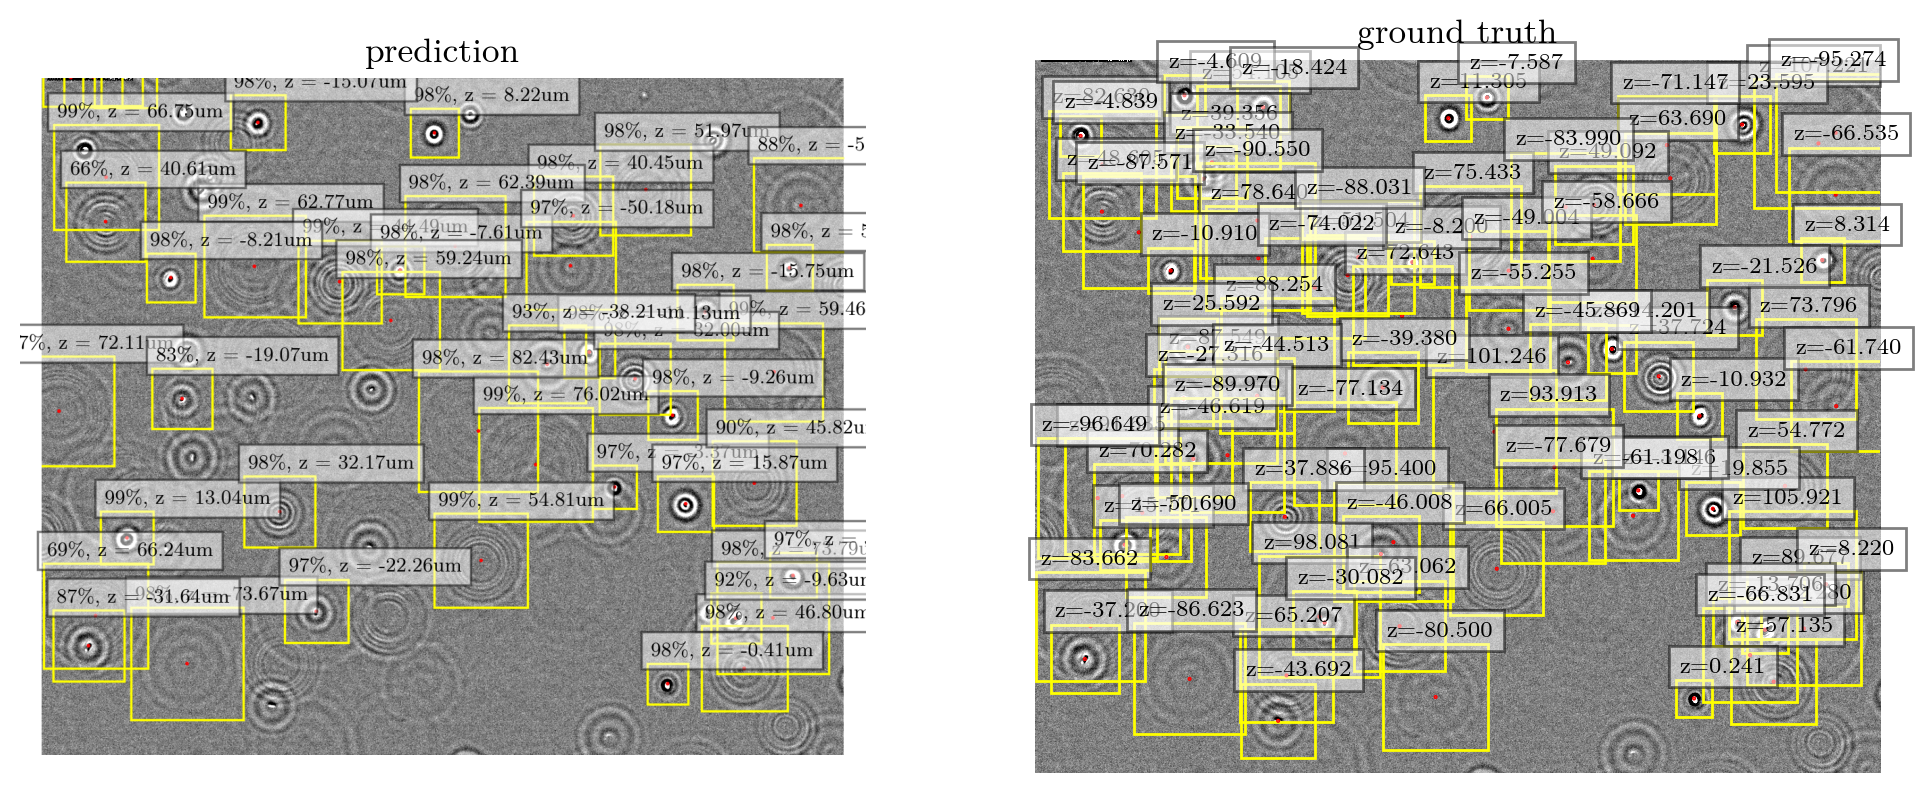

In [4]:
import matplotlib.pyplot as plt

img = random_image()
res = model.predict(img, imgsz=imgsz, conf=0.65, background=2e4)
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.title("prediction")
plt.imshow(res[0].plot(vmin=1.95e4, vmax=2.05e4, scale=250))
plt.axis("off")
plt.subplot(122)
plt.title("ground truth")
plot_gt(img, plt.gca(), (1280,1080))
plt.show()

Let's assess the localization error and precision and recall:

In [4]:
res = model.val(data="../datasets/yundon_test.yaml", workers=0, imgsz=[1280], conf=0.65)

Ultralytics 8.3.79 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)


YOLO11n-zaxis summary (fused): 118 layers, 2,725,252 parameters, 0 gradients, 6.7 GFLOPs
image size: 1280


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_yundon/labels/test.cache... 1501 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1501/1501 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 94/94 [00:09<00:00, 10.34it/s]


                   all       1501      86566      0.792       0.83      0.786      0.755       1.35        2.3
Speed: 0.2ms preprocess, 2.4ms inference, 0.0ms loss, 0.2ms postprocess per image


Let's look at the localization error:

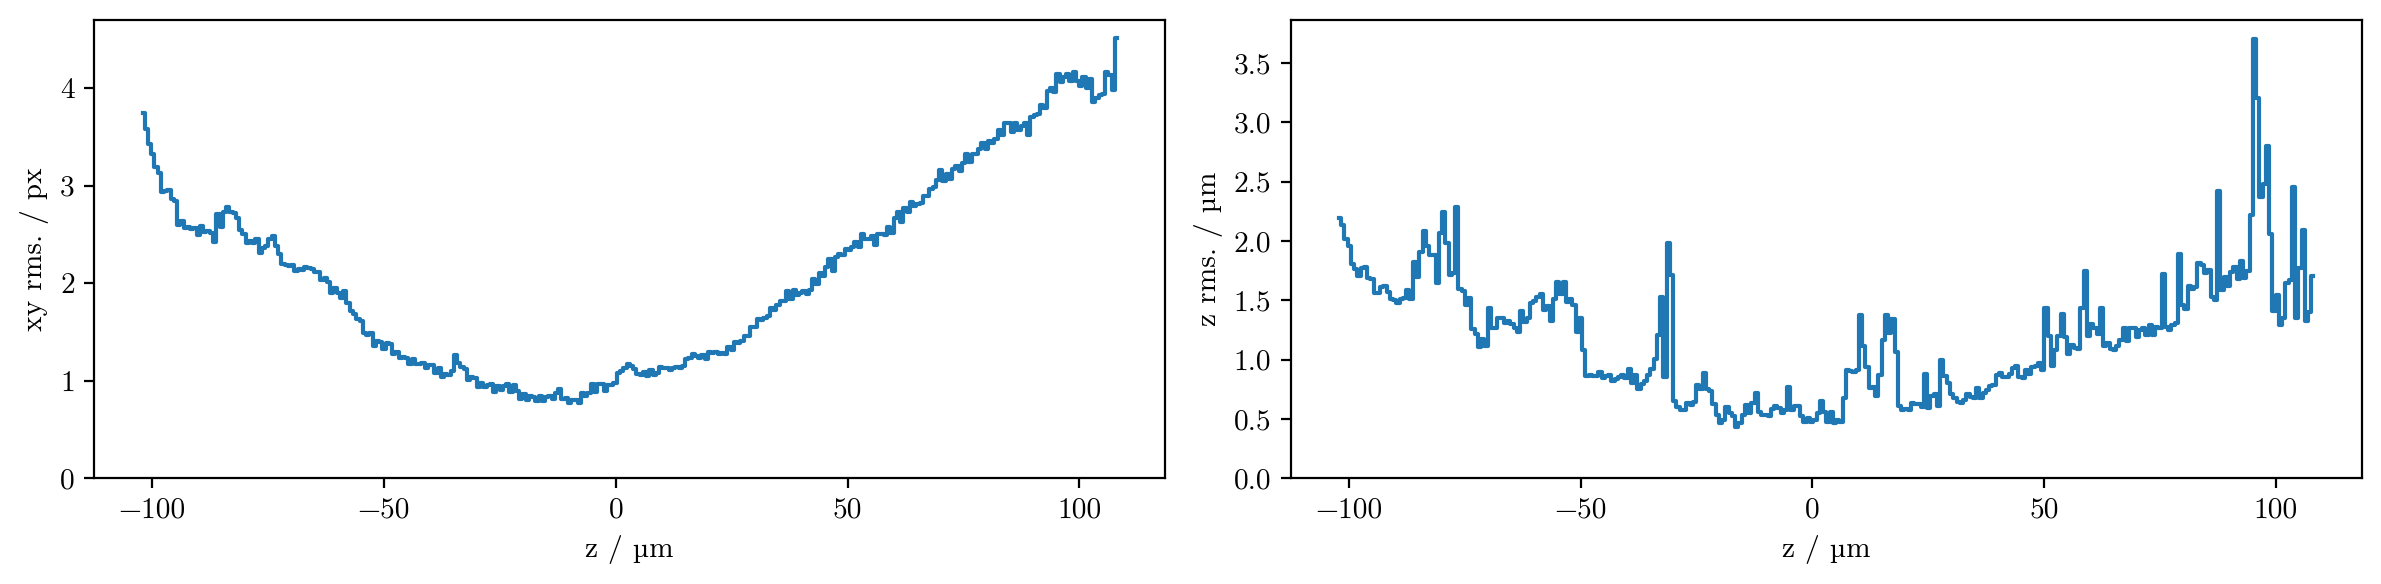

In [10]:
bins=300
from scipy.stats import binned_statistic
plt.figure(figsize=(12,3))
plt.subplot(121)
crlb = np.load("crlb_results.npz")
z = np.linspace(-102,108,bins)
crlb_xy = np.interp(z, crlb["z_space"], crlb["std_xy"])
k=10
crlb_z = np.interp(z, crlb["z_space"][k//2:-k//2:k], np.convolve(crlb["std_z"], np.ones(k)/k, mode='same')[k//2:-k//2:k])
y, x,_ = binned_statistic(res.z_pairs[6][0], res.xy_distances[6]**2, bins=bins)
plt.step(z,np.sqrt(y), where="mid")
# plt.hist(res.z_pairs[6][0], bins=bins)
# plt.plot(z, crlb_xy, "--", c="k", lw=0.9)
# plt.yscale("log")
plt.ylim(0)
plt.xlabel("z / µm")
plt.ylabel("xy rms. / px")

plt.subplot(122)
y, x,_ = binned_statistic(res.z_pairs[6][0], np.subtract(*res.z_pairs[6])**2, bins=bins)
plt.step(z,np.sqrt(y), label="no overlap", where="mid")
k=10
# plt.plot(z,crlb_z, "--", c="k", lw=0.9, label="CR lower bound")
plt.ylim(0)
# plt.yscale("log")
plt.xlabel("z / µm")
plt.ylabel("z rms. / µm")
# plt.ylim(0,7.5)
plt.tight_layout()

Is there a bias?

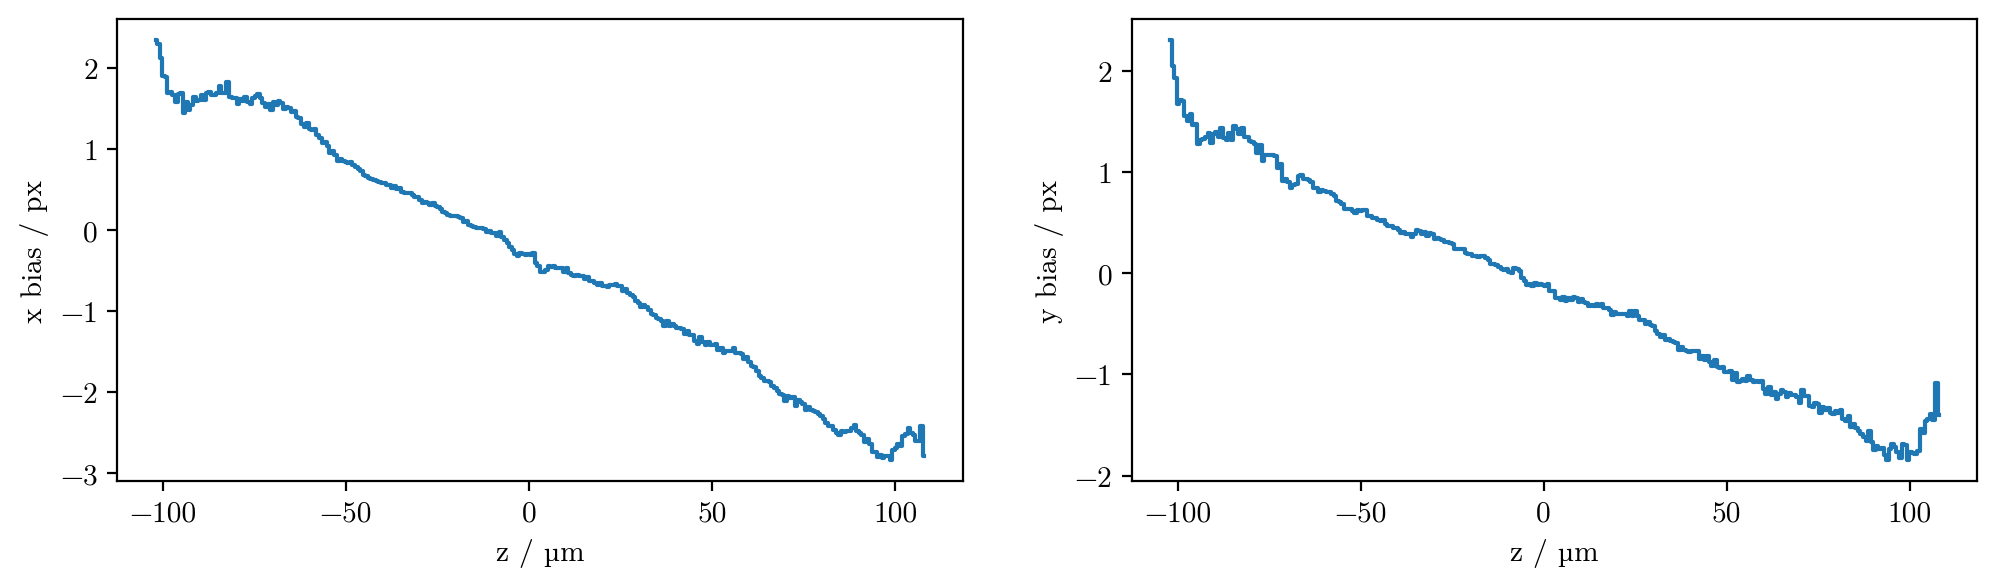

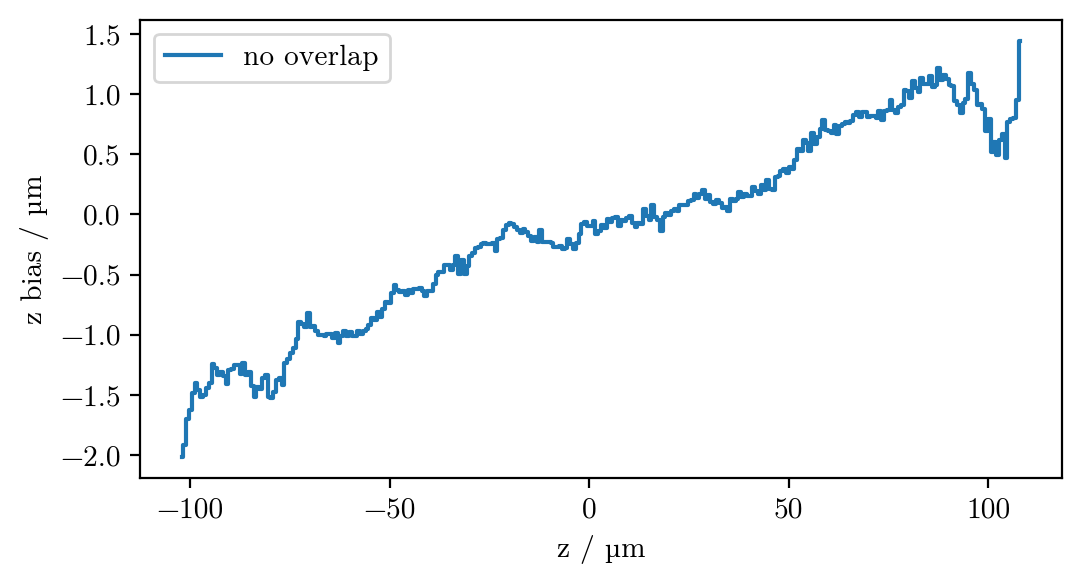

In [49]:
bins=300
plt.figure(figsize=(12,3))
plt.subplot(121)
z = np.linspace(-102,108,bins)
y, x,_ = binned_statistic(res.z_pairs[6][0], np.subtract(*res.kpt_pairs[6][0]), bins=bins)
plt.step(z,y, where="mid")
plt.xlabel("z / µm")
plt.ylabel("x bias / px")
plt.subplot(122)

y, x,_ = binned_statistic(res.z_pairs[6][0], np.subtract(*res.kpt_pairs[6][1]), bins=bins)
plt.step(z,y, where="mid", label="with overlap")
# plt.hist(res.z_pairs[6][0], bins=bins)
plt.xlabel("z / µm")
plt.ylabel("y bias / px")

plt.figure(figsize=(5.5,3))
y, x,_ = binned_statistic(res.z_pairs[6][0], np.subtract(*res.z_pairs[6]), bins=bins)
plt.step(z,y, label="no overlap", where="mid")
plt.xlabel("z / µm")
plt.ylabel("z bias / µm")
plt.legend()
plt.tight_layout()

Which z-posotions do we miss the most?

Text(0, 0.5, 'miss rate')

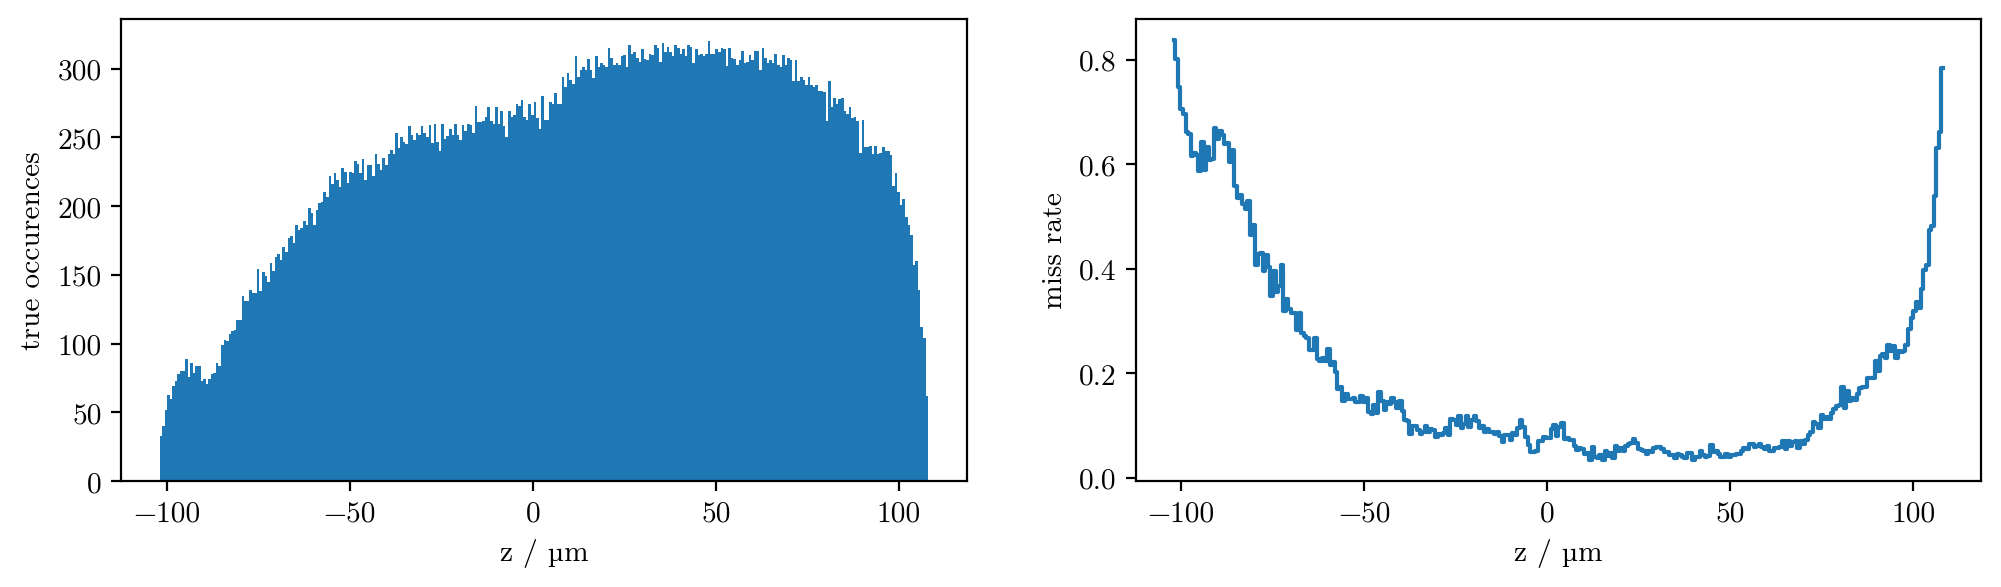

In [27]:
bins=300
plt.figure(figsize=(12,3))
plt.subplot(121)
z = np.linspace(-102,108,bins)
plt.hist(res.z_pairs[6][0], bins=bins)
plt.xlabel("z / µm")
plt.ylabel("true occurences")
plt.subplot(122)

y, x,_ = binned_statistic(res.fn[6].reshape(2,-1)[0], res.fn[6].reshape(2,-1)[1], bins=bins)
plt.step(z,y, where="mid", label="with overlap")
# plt.hist(res.z_pairs[6][0], bins=bins)
plt.xlabel("z / µm")
plt.ylabel("miss rate")

Let's also plot the true vs predicted x,y,z:

/tmp/ipykernel_949939/1304322778.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


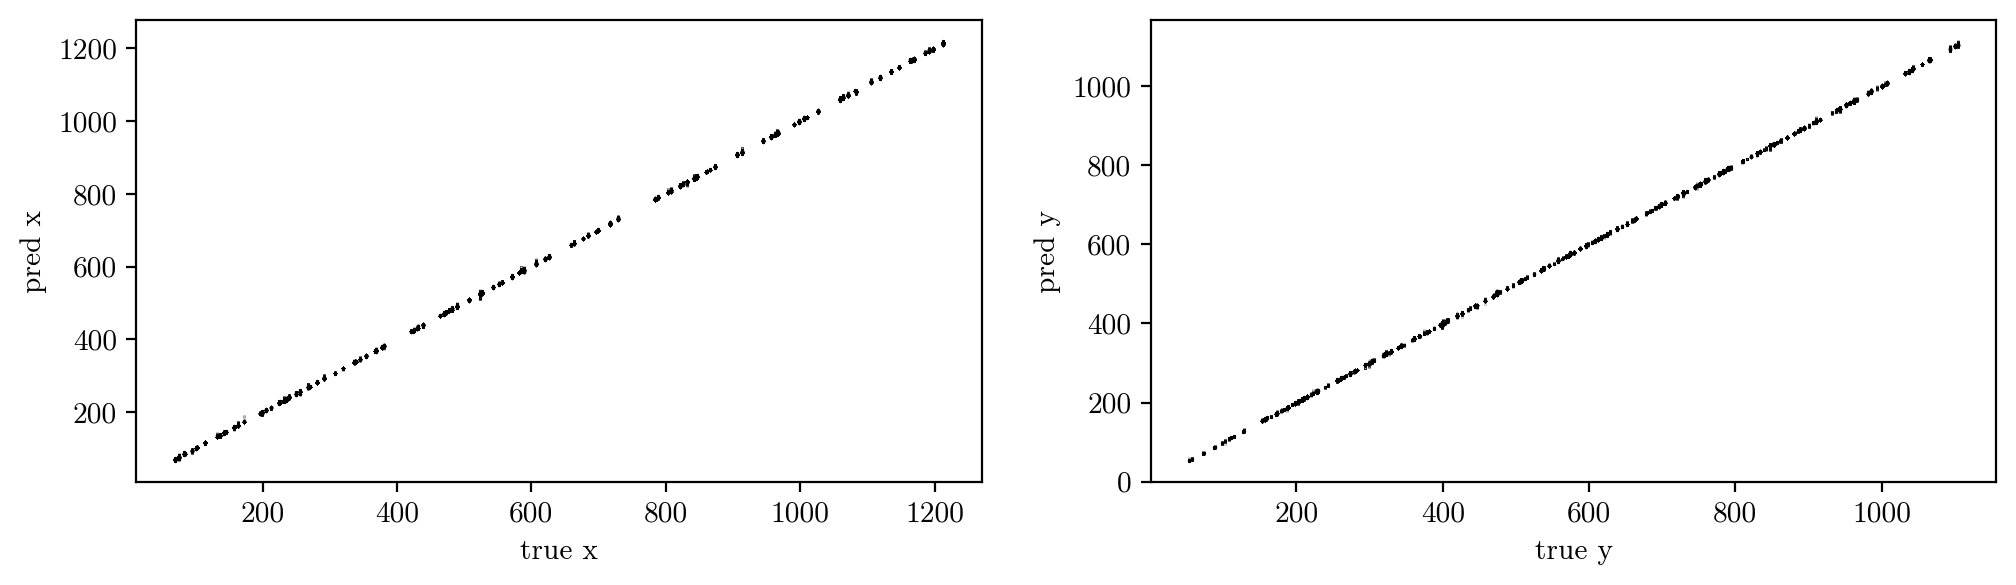

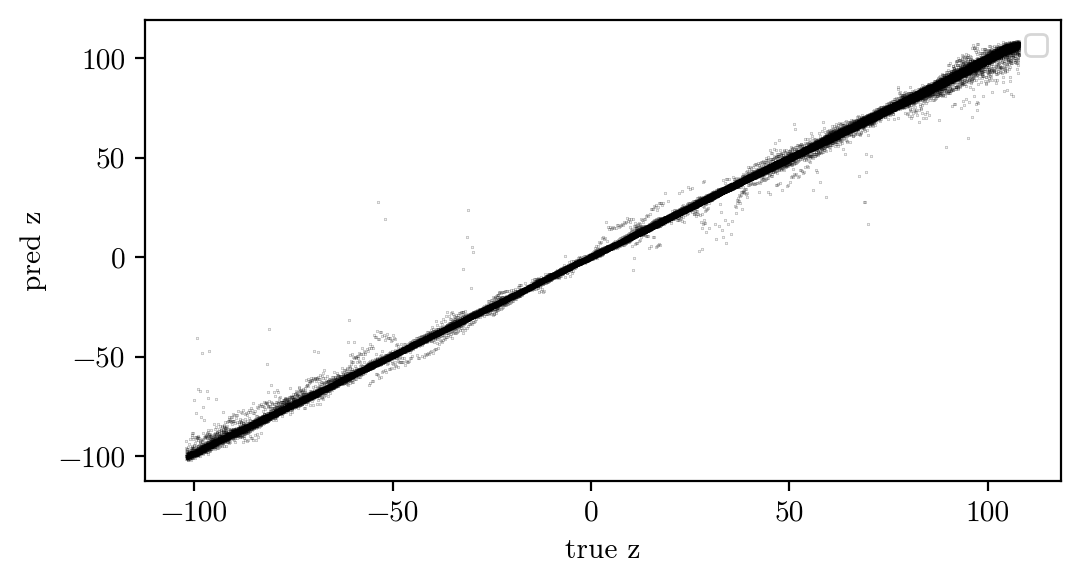

In [19]:
bins=300
plt.figure(figsize=(12,3))
plt.subplot(121)
z = np.linspace(-102,108,bins)
plt.plot(res.kpt_pairs[6][0][0],res.kpt_pairs[6][0][1],"k.",ms=0.2, alpha=0.7)
plt.xlabel("true x")
plt.ylabel("pred x")
plt.subplot(122)

plt.plot(res.kpt_pairs[6][1][0],res.kpt_pairs[6][1][1],"k.",ms=0.2, alpha=0.7)
plt.xlabel("true y")
plt.ylabel("pred y")

plt.figure(figsize=(5.5,3))
plt.plot(res.z_pairs[6][0],res.z_pairs[6][1],"k.",ms=0.2, alpha=0.7)
plt.xlabel("true z")
plt.ylabel("pred z")
plt.legend()
plt.tight_layout()

Previously, the following technique was also tested, when less real data was available.

How do we get the model to be more effective on the actual data? Since the applicability of the model trained on synthetic data seems to be quite narrow, one approach is **fine tuning** a model on real data, i.e. re-training a pre-trained model on a smaller dataset.

In [ ]:
import YOLOtrack11
modelfnames = ["../../ultralytics/runs/pose/train122/weights/last.pt","../../ultralytics/runs/pose/train129/weights/last.pt", "../../ultralytics/runs/pose/train122/weights/last.pt","../../ultralytics/runs/pose/train129/weights/last.pt","../../ultralytics/runs/pose/train143/weights/last.pt"]
models = [YOLOtrack11.YOLOtrack11(modelfname) for modelfname in modelfnames]
# print(model.model.model)
print("loaded")
# results = model.train(data="data_gen/data.yaml", epochs=100, imgsz=512,)
results = []
filenames = [f'../datasets/dataset_subpixel.yaml', f'../datasets/dataset_subpixel.yaml', f'../datasets/dataset_subpixel_real.yaml', f'../datasets/dataset_subpixel_real.yaml', f'../datasets/dataset_subpixel_real.yaml']
for model, fname  in zip(models, filenames):
    results.append(model.val(save=False,z_corr=False, data=fname, conf=0.8))

print("test")

loaded
Ultralytics 8.3.51 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 276 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_subpixel/labels/val.cache... 5000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5000/5000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 313/313 [00:08<00:00, 38.32it/s]


                   all       5000     307625      0.981      0.884       0.94      0.928       1.12       1.08
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.3.51 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 276 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_subpixel/labels/val.cache... 5000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5000/5000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 313/313 [00:08<00:00, 38.46it/s]


                   all       5000     307625      0.981      0.912      0.954      0.942       2.53       1.16
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.3.51 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 276 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


...

YOLO11n-zaxis summary (fused): 276 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_subpixel/labels/val_real.cache... 1196 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1196/1196 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 75/75 [00:02<00:00, 37.21it/s]


                   all       1196      63150      0.687      0.894      0.737      0.469       13.5       2.06
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.3.51 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 276 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_subpixel/labels/val_real.cache... 1196 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1196/1196 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 75/75 [00:01<00:00, 38.07it/s]

                   all       1196      63150       0.86      0.888      0.834      0.497       2.77       1.93
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
test


Here is an overview of the $xy$ and $z$ root mean square error on the whole training set

In [ ]:

for res, name in zip(results, ["no fine tune","\nz fine tune","\nreal data:\nno fine tune","\n z fine tune", "\n z fine tune(real)"]):
    print(name)
    print("xy_rms =",res.xy_rms[5],"px")
    print("z_rms =",res.z_rms[5],"um")


no fine tune
xy_rms = 1.0736179 px
z_rms = 1.118449 um

z fine tune
xy_rms = 1.1266402 px
z_rms = 1.785709 um

real data:
no fine tune
xy_rms = 1.7527341 px
z_rms = 10.45958 um

 z fine tune
xy_rms = 1.7790414 px
z_rms = 11.790072 um

 z fine tune(real)
xy_rms = 1.4531882 px
z_rms = 4.3716326 um


Ultralytics 8.3.51 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 276 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_subpixel/labels/val_snr10-13.cache... 10000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10000/10000 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 625/625 [00:24<00:00, 25.48it/s]


                   all      10000     603115      0.989       0.91      0.954      0.941       3.18        1.1
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.3.51 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 276 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


val: Scanning /home/jupyter-till/git/YOLOTrack11/datasets/Dataset_subpixel/labels/val_real.cache... 1044 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1044/1044 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     z rms.    xy rms.: 100%|██████████| 66/66 [00:02<00:00, 25.00it/s]

                   all       1044      55091      0.705      0.881      0.749       0.48       12.4       2.02
Speed: 0.0ms preprocess, 0.6ms inference, 0.0ms loss, 0.2ms postprocess per image


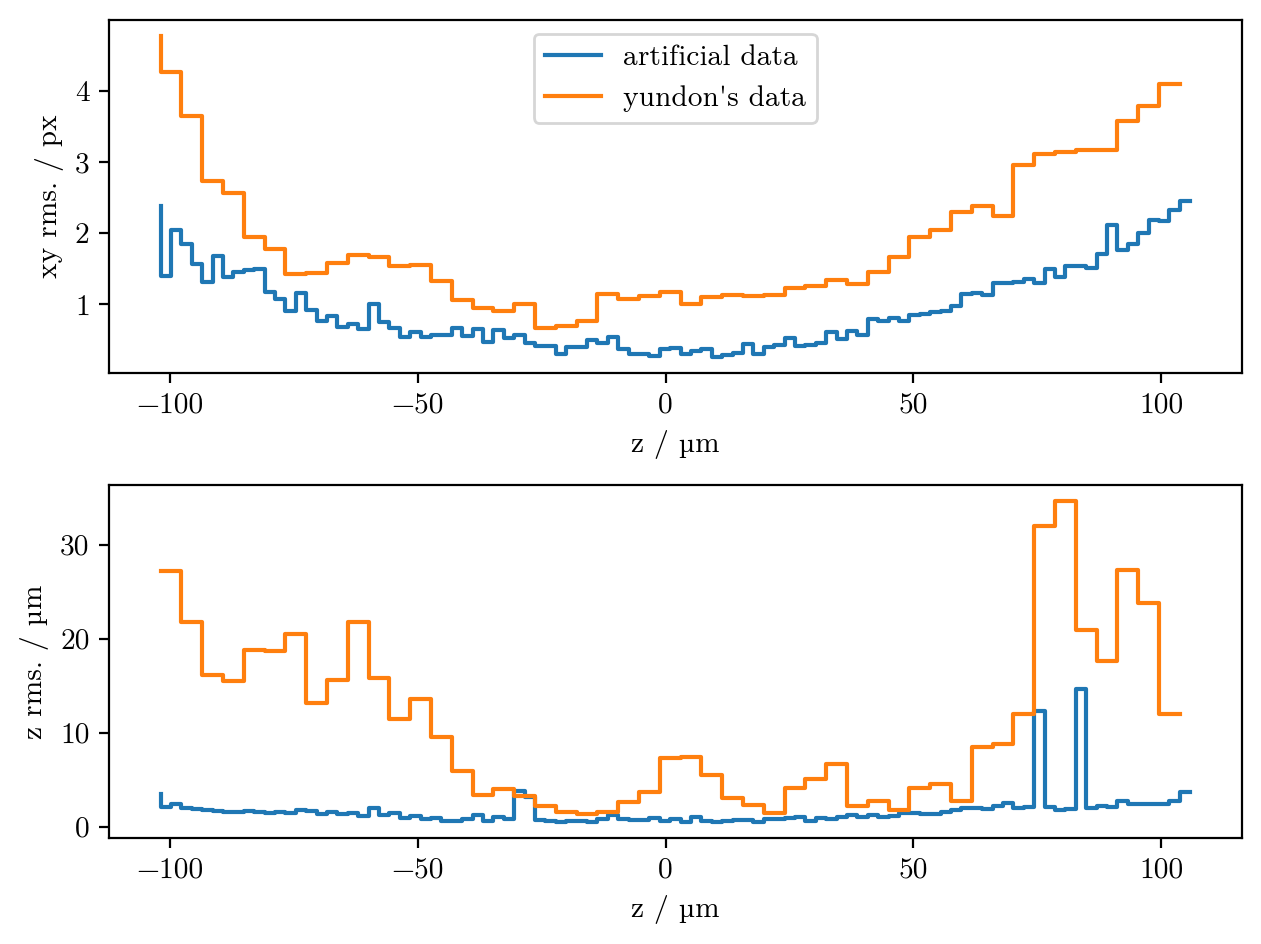

In [ ]:

results = []
for d in ["snr10-13.yaml", "dataset_subpixel_real.yaml"]:
    model = YOLOtrack11.YOLOtrack11(f"../../ultralytics/runs/pose/train122/weights/last.pt")
    results.append(model.val(save=False,z_corr=False, data=f'../datasets/{d}', workers=0, conf=0.8))

bins = 100

plt.subplot(211)
y, x,_ = binned_statistic(results[0].z_pairs[5][0], results[0].xy_distances[5]**2, bins=bins)
plt.step(x[:-1],np.sqrt(y), label="artificial data")
# plt.plot(clrb["z_space"], 50/0.75*clrb["std_xy"], "--")

plt.xlabel("z / µm")
plt.ylabel("xy rms. / px")
# plt.legend()
plt.subplot(212)
y, x,_ = binned_statistic(results[0].z_pairs[5][0], np.subtract(*results[0].z_pairs[5])**2, bins=bins)
plt.step(x[:-1],np.sqrt(y))
k=10
# plt.plot(clrb["z_space"][k//2:-k//2:k], 50/0.75*np.convolve(clrb["std_z"], np.ones(k)/k, mode='same')[k//2:-k//2:k], "--")
plt.xlabel("z / µm")
plt.ylabel("z rms. / µm")
# plt.ylim(0,7.5)
bins = 50
# plt.figure(figsize=(10,8))
plt.subplot(211)
y, x,_ = binned_statistic(results[1].z_pairs[5][0], results[1].xy_distances[5]**2, bins=bins)
plt.step(x[:-1],np.sqrt(y), label="yundon's data")
plt.xlabel("z / µm")
plt.ylabel("xy rms. / px")
plt.legend()

plt.subplot(212)
y, x,_ = binned_statistic(results[1].z_pairs[5][0], np.subtract(*results[1].z_pairs[5])**2, bins=bins)
plt.step(x[:-1],np.sqrt(y))
plt.xlabel("z / µm")
plt.ylabel("z rms. / µm")
# # plt.ylim(0,7.5)

plt.tight_layout()


Text(0, 0.5, 'pred. z / µm')

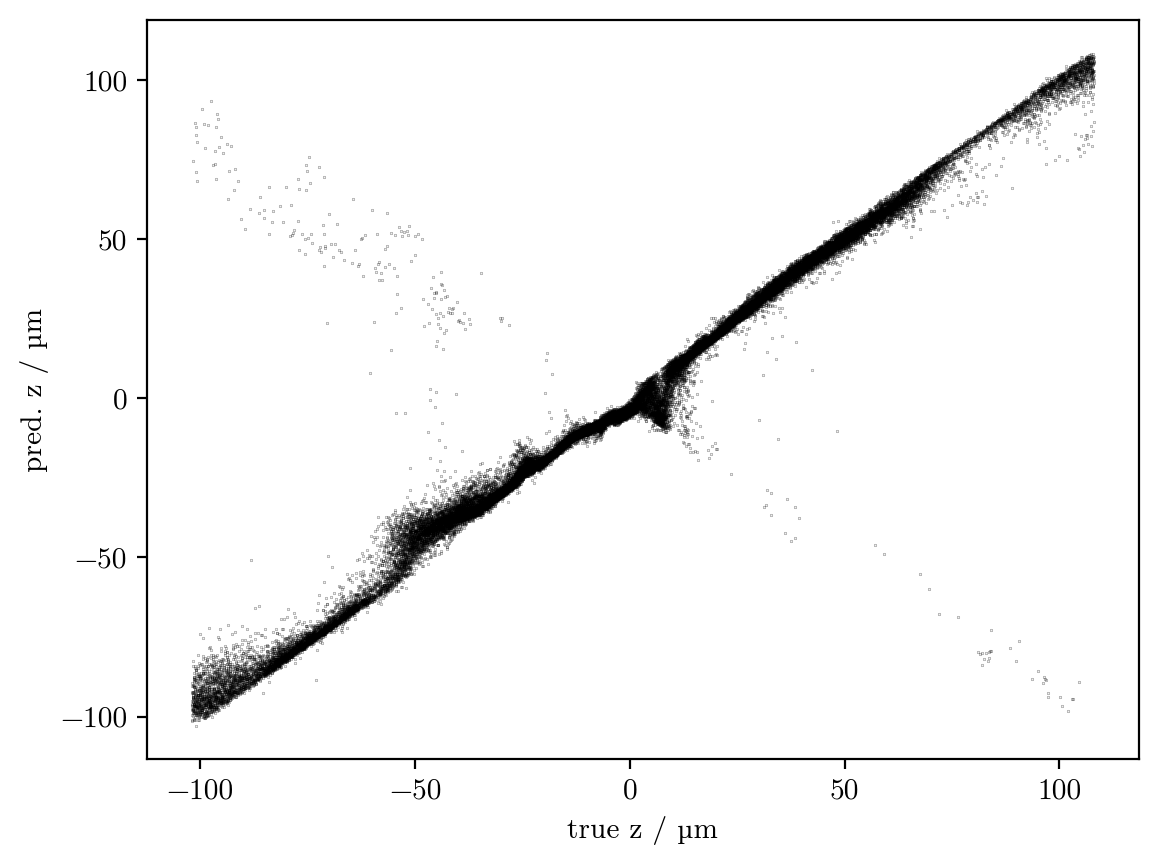

In [ ]:

plt.plot(results[1].z_pairs[5][0], results[1].z_pairs[5][1], "k.", ms=0.2, alpha=0.9)
plt.xlabel("true z / µm")
plt.ylabel("pred. z / µm")